# Spectral Galerkin

We now want to use a different set of basis functions. Instead of the compactly supported hat functions we want to use Legendre polynomials $P_n(x)$ which form a set of orthogonal basis vectors of $L^2([-1,1])$. Again we try to solve the Poisson equation $\Delta u = f$.

In [250]:
import numpy as np
from numpy.polynomial.legendre import legval
from numpy.polynomial.legendre import leggauss
from numpy.polynomial.legendre import legder
import matplotlib.pyplot as plt

In [251]:
def legendre(i, x):
    coeffs = np.zeros(i + 1)
    coeffs[i] = 1
    return legval(x, coeffs)

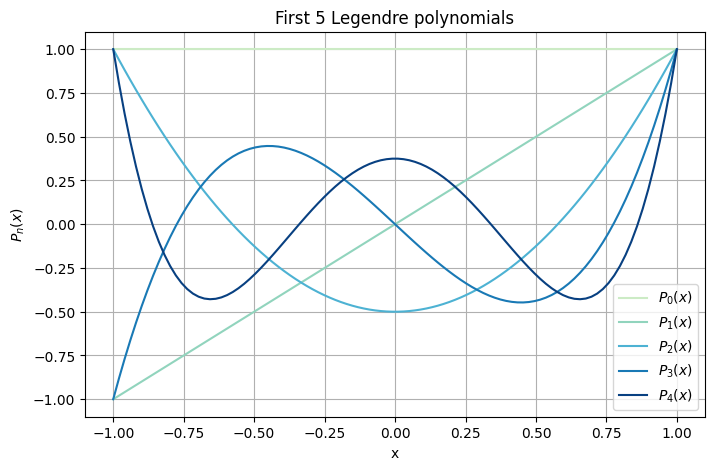

In [252]:
N = 5
x = np.linspace(-1,1,100)
colors = plt.cm.GnBu(np.linspace(0.25, 1, N))
plt.figure(figsize=(8,5))
for n in range(N):
    plt.plot(x, legendre(n, x), label=f'$P_{n}(x)$', color=colors[n])
plt.xlabel('x')
plt.ylabel('$P_n(x)$')
plt.title('First 5 Legendre polynomials')
plt.legend()
plt.grid(True)
plt.show()

However the Legendre polynomials itself are not useful for our boundary conditions because they do not satisfy $P_n(\pm1) = 0$. Instead we can consider $P_n(x) - P_{n+2}(x)$

In [253]:
def phi_spec(i, x):
    return legendre(i, x) - legendre(i + 2, x)

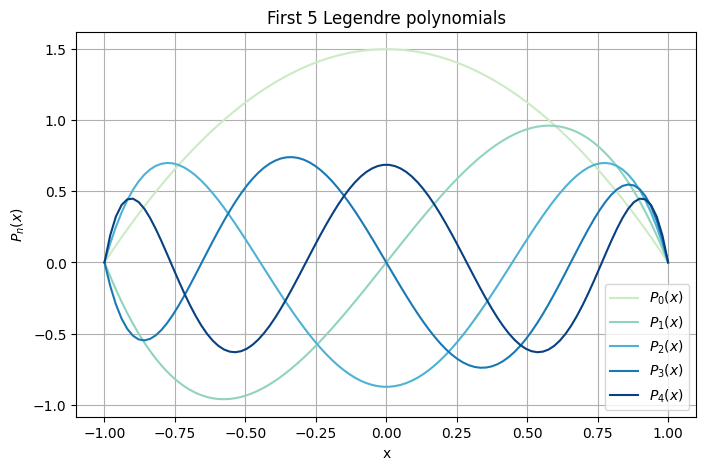

In [254]:
N = 5
x = np.linspace(-1,1,100)
colors = plt.cm.GnBu(np.linspace(0.25, 1, N))
plt.figure(figsize=(8,5))
for n in range(5):
    plt.plot(x, phi_spec(n, x), label=f'$P_{n}(x)$', color=colors[n])
plt.xlabel('x')
plt.ylabel('$P_n(x)$')
plt.title('First 5 Legendre polynomials')
plt.legend()
plt.grid(True)
plt.show()

Therefore the set of functions $\phi_n(x) = P_n(x) - P_{n+2}(x)$ are a suitable basis. The downside of these basis functions is that the matrix $A$ is not as simple anymore

In [255]:
def legendre_deriv(n, x):
    coeffs = np.zeros(n + 1)
    coeffs[n] = 1
    deriv_coeffs = legder(coeffs)
    return legval(x, deriv_coeffs)

def phi_spec_deriv(n, x):
    return legendre_deriv(n,x) - legendre_deriv(n+2,x)

Text(0.5, 1.0, 'basis functions polynomials dervatives')

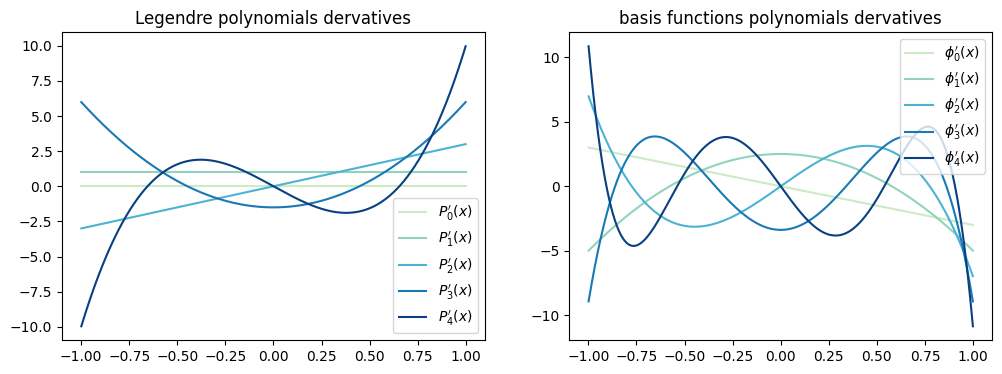

In [256]:
N = 5
x = np.linspace(-0.999,0.999,1000)
colors = plt.cm.GnBu(np.linspace(0.25, 1, N))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for n in range(5):
    axes[0].plot(x, legendre_deriv(n, x), label=rf"$P_{n}'(x)$", color=colors[n])
    axes[1].plot(x, phi_spec_deriv(n, x), label=rf"$\phi_{n}'(x)$", color=colors[n])

axes[0].legend()
axes[1].legend()
axes[0].set_title("Legendre polynomials dervatives")
axes[1].set_title("basis functions polynomials dervatives")

With the derivatives of the basis functions we can compute the stiffness matrix $A_{ij} = - \int_\Omega \phi_i(x) \phi_j(x) \mathrm{d}x$

In [257]:
N = 5
pts, wts = leggauss(20)   # quadrature points and weights on [-1,1]

A = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        integrand = phi_spec_deriv(i, pts) * phi_spec_deriv(j, pts)
        A[i,j] = np.dot(wts, integrand)

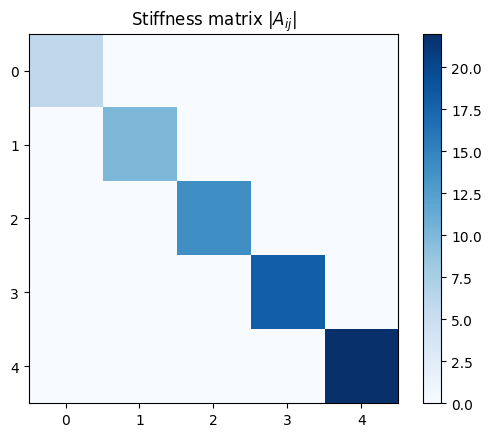

In [258]:
plt.imshow(np.abs(A), cmap='Blues')
plt.colorbar()
plt.title('Stiffness matrix $|A_{ij}|$')
plt.show()

The stiffness matrix is diagonal, therefore solving the equation $A \mathbf{c} = \mathbf{b}$ is trivial and we get $c_i = \frac{b_i}{A_{ii}}$. As a first example we again use $f = \pi^2 \sin(\pi x)$

In [259]:
f = lambda x: np.pi**2 * np.sin(np.pi * x)

b = np.zeros(N)
for i in range(N):
    integrand = phi_spec(i, pts) * f(pts)
    b[i] = np.dot(wts, integrand)

In [260]:
c = b / np.diag(A)

x = np.linspace(-1, 1, 400)
u_spec = sum(c[i] * phi_spec(i, x) for i in range(N))

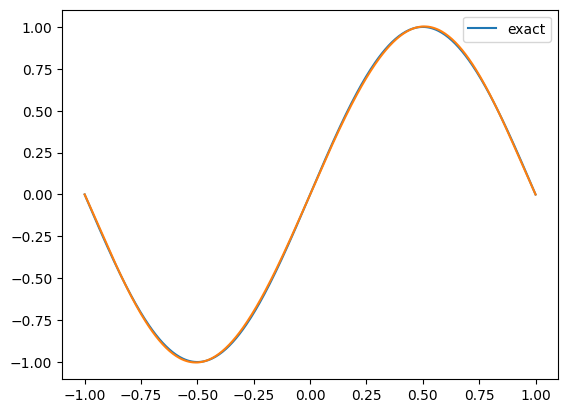

In [261]:
plt.plot(x, np.sin(np.pi*x), label='exact')
plt.plot(x, u_spec)
plt.legend()

In [262]:
# solving the possion equation with legendre polynomials as basis functions and gaussian quadrature
def solve_poisson_spectral(N, f, u_exact):
    pts, wts = leggauss(2 * N)
    # assemble A
    A = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            integrand = phi_spec_deriv(i, pts) * phi_spec_deriv(j, pts)
            A[i,j] = np.dot(wts, integrand)
    

    # assemble b
    b = np.zeros(N)
    for i in range(N):
        integrand = phi_spec(i, pts) * f(pts)
        b[i] = np.dot(wts, integrand)

    # solve c = b / A
    c = b / np.diag(A)

    # reconstruct u on a fine grid
    x = np.linspace(-1, 1, 500)
    u_spec = sum(c[i] * phi_spec(i, x) for i in range(N))

    #compute errors
    errors = np.abs(u_spec - u_exact(x))
    l2_error = np.sqrt(np.trapezoid((u_spec - u_exact(x))**2, x))

    return x, u_spec, errors, l2_error

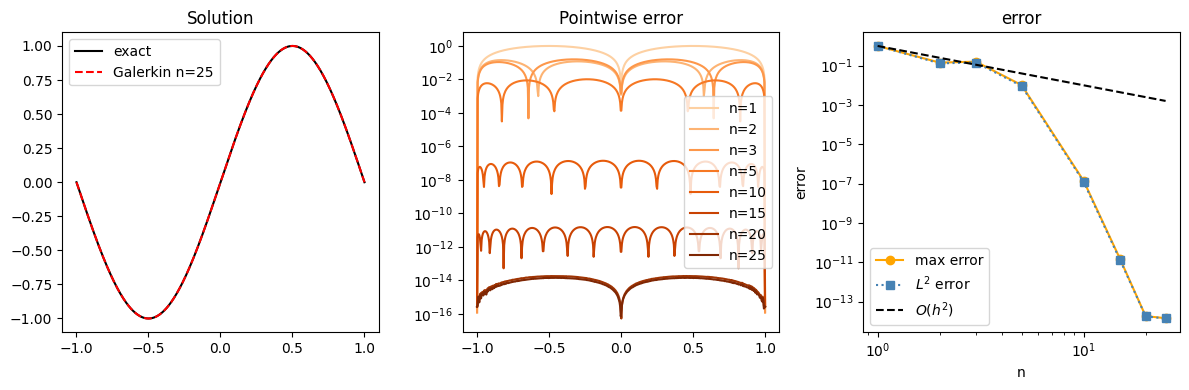

In [263]:
f       = lambda x: np.pi**2 * np.sin(np.pi * x)
u_exact = lambda x: np.sin(np.pi*x)

N_vals    = [1, 2, 3, 5, 10, 15, 20, 25]
u_specs   = []
errors    = []
max_error = []
l2_errors = []

for N in N_vals:
    x, u_spec, error, l2 = solve_poisson_spectral(N, f, u_exact)
    u_specs.append(u_spec)
    errors.append(error)
    max_error.append(np.max(error))
    l2_errors.append(l2)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
colors = plt.cm.Oranges(np.linspace(0.25, 1, len(N_vals)))

# Left: solution for largest n
n = N_vals[-1]
axes[0].plot(x, u_exact(x), 'k-', label='exact')
axes[0].plot(x, u_specs[-1], '--', label=f'Galerkin n={n}', color="red")
axes[0].legend()
axes[0].set_title('Solution')

# Right: pointwise error for each n
for i, n in enumerate(N_vals):
    axes[1].plot(x, errors[i], label=f'n={n}', color=colors[i])
axes[1].legend()
axes[1].set_yscale("log")
axes[1].set_title('Pointwise error')

axes[2].loglog(N_vals, max_error, 'o-', color='orange', label='max error')
axes[2].loglog(N_vals, l2_errors, 's:', color='steelblue', label='$L^2$ error')
axes[2].loglog(N_vals, 1/np.array(N_vals)**2, 'k--', label='$O(h^2)$')
axes[2].set_xlabel('n')
axes[2].set_ylabel('error')
axes[2].legend()
axes[2].set_title('error')


plt.tight_layout()
plt.show()